# Capstone 04 - Airline Passengers Time-Series Dashboard

> **MLCourse · Data Science Foundations · 06_capstone_projects**

## Project brief
A 1950s airline analyst's retrospective: quantify the growth trajectory, map the
seasonal staffing pattern, decompose trend from seasonality manually, and flag
anomalous months. One executive dashboard at the end.

## Dataset
Seaborn `flights` - monthly airline passengers 1949-1960 (144 rows, long format:
year, month, passengers). THE canonical teaching series: strong trend +
multiplicative seasonality.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    flights = sns.load_dataset("flights")
except Exception as e:
    print("Offline? Load once online; seaborn caches afterwards.", e)
    raise

print(flights.shape, "\n", flights.head(3))

(144, 3) 
    year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132


## Phase 1 - Build a proper time series

Long format (year | month-name) → real DatetimeIndex. This construction pattern
is used constantly in practice.

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
Name: passengers, dtype: int64

date
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: passengers, dtype: int64

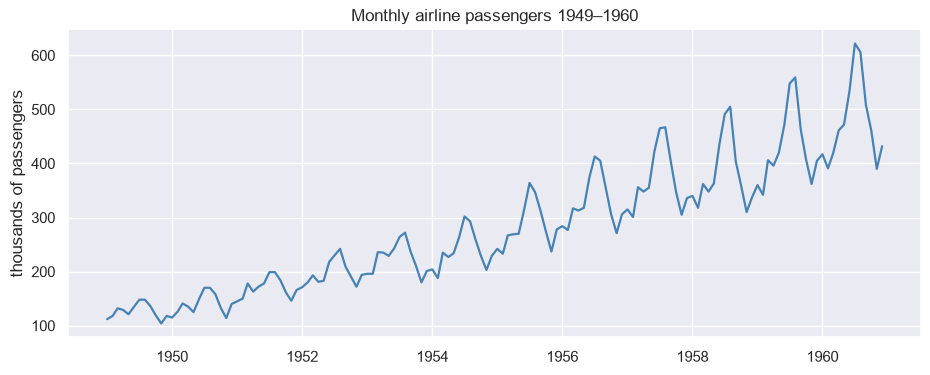

In [2]:
ts = (
    flights.assign(date=pd.to_datetime(flights["year"].astype(str)
                                       + "-"
                                       + flights["month"].astype(str)
                                       + "-01"))
            .set_index("date")
            .sort_index()["passengers"]
    .rename("passengers").astype(int)
)
assert ts.index.is_monotonic_increasing and len(ts) == 144
display(ts.head(4), ts.tail(4))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts, lw=1.6, color="steelblue")
ax.set_title("Monthly airline passengers 1949-1960")
ax.set_ylabel("thousands of passengers")
plt.show()

## Phase 2 - Trend & growth quantification

overall CAGR 1949-1960: 13.1%
avg YoY total growth 1949-53 : 15.5%
avg YoY total growth 1954-60 : 12.3%


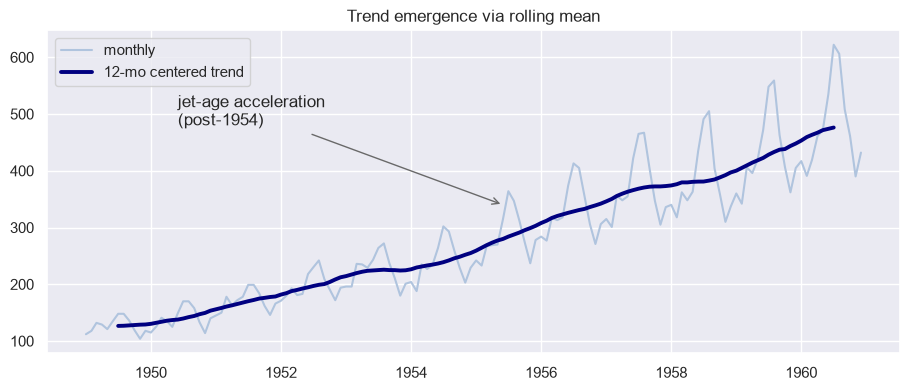

In [3]:
trend12 = ts.rolling(12, center=True).mean()          # annual centered average

cagr = (ts.iloc[-1] / ts.iloc[0]) ** (1 / 11) - 1     # 1949→1960 = 11 intervals
print(f"overall CAGR 1949-1960: {cagr:.1%}")

# Phase comparison: pre/post 1954 kink visible in the raw plot.
pre  = ts.loc[: "1953"].resample("YE").sum()
post = ts.loc["1954":].resample("YE").sum()
growth_pre  = pre.pct_change().mean()
growth_post = post.pct_change().mean()
print(f"avg YoY total growth 1949-53 : {growth_pre:.1%}")
print(f"avg YoY total growth 1954-60 : {growth_post:.1%}")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(ts, color="lightsteelblue", label="monthly")
ax.plot(trend12, color="navy", lw=2.8, label="12-mo centered trend")
ax.annotate("jet-age acceleration\n(post-1954)",
            xy=(pd.Timestamp("1955-06-01"), 340),
            xytext=(pd.Timestamp("1950-06-01"), 480),
            arrowprops=dict(arrowstyle="->", color="dimgray"))
ax.legend(); ax.set_title("Trend emergence via rolling mean")
plt.show()

## Phase 3 - Seasonality profile

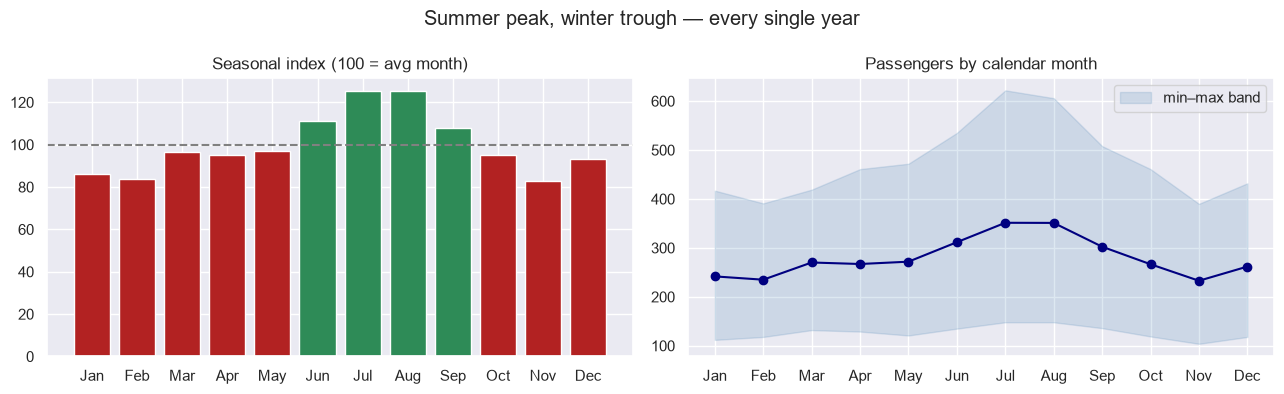

peak month Jul ≈ 125 · trough Nov ≈ 83
staffing implication: Jul needs 51% more capacity than Nov


In [4]:
month_profile = ts.groupby(ts.index.month).agg(["mean", "min", "max"])
seasonal_index = month_profile["mean"] / ts.mean() * 100   # 100 = average month

names = ["Jan","Feb","Mar","Apr","May","Jun",
         "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 13), seasonal_index.values,
            color=["seagreen" if v >= 100 else "firebrick"
                   for v in seasonal_index])
axes[0].axhline(100, ls="--", color="gray")
axes[0].set_xticks(range(1, 13), names)
axes[0].set_title("Seasonal index (100 = avg month)")

axes[1].fill_between(range(1, 13),
                     month_profile["min"], month_profile["max"],
                     alpha=.18, color="steelblue", label="min-max band")
axes[1].plot(range(1, 13), month_profile["mean"], "o-", color="navy")
axes[1].set_xticks(range(1, 13), names)
axes[1].legend(); axes[1].set_title("Passengers by calendar month")

plt.suptitle("Summer peak, winter trough - every single year")
plt.tight_layout(); plt.show()

peak, trough = seasonal_index.idxmax(), seasonal_index.idxmin()
print(f"peak month {names[peak-1]} ≈ {seasonal_index.max():.0f} · "
      f"trough {names[trough-1]} ≈ {seasonal_index.min():.0f}")
print("staffing implication:", f"{names[peak-1]} needs "
      f"{seasonal_index.max()/seasonal_index.min()-1:.0%} more capacity than {names[trough-1]}")

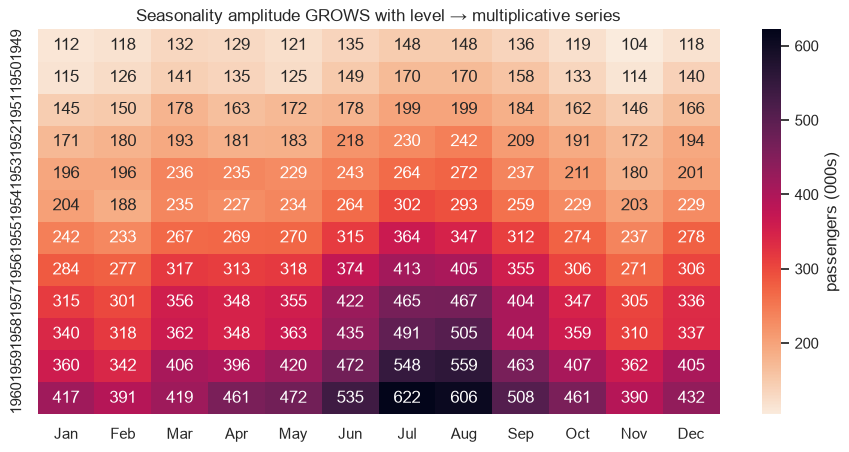

In [5]:
# The classic month × year heatmap:
heat = flights.pivot(index="year", columns="month", values="passengers")[names]

plt.figure(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt="d", cmap="rocket_r",
            cbar_kws={"label": "passengers (000s)"})
plt.title("Seasonality amplitude GROWS with level → multiplicative series")
plt.xlabel(""); plt.ylabel("")
plt.show()

## Phase 4 - Manual decomposition (teach the machine!)

Classical additive decomposition done BY HAND so nothing is magic:
`series = trend + seasonal + residual`

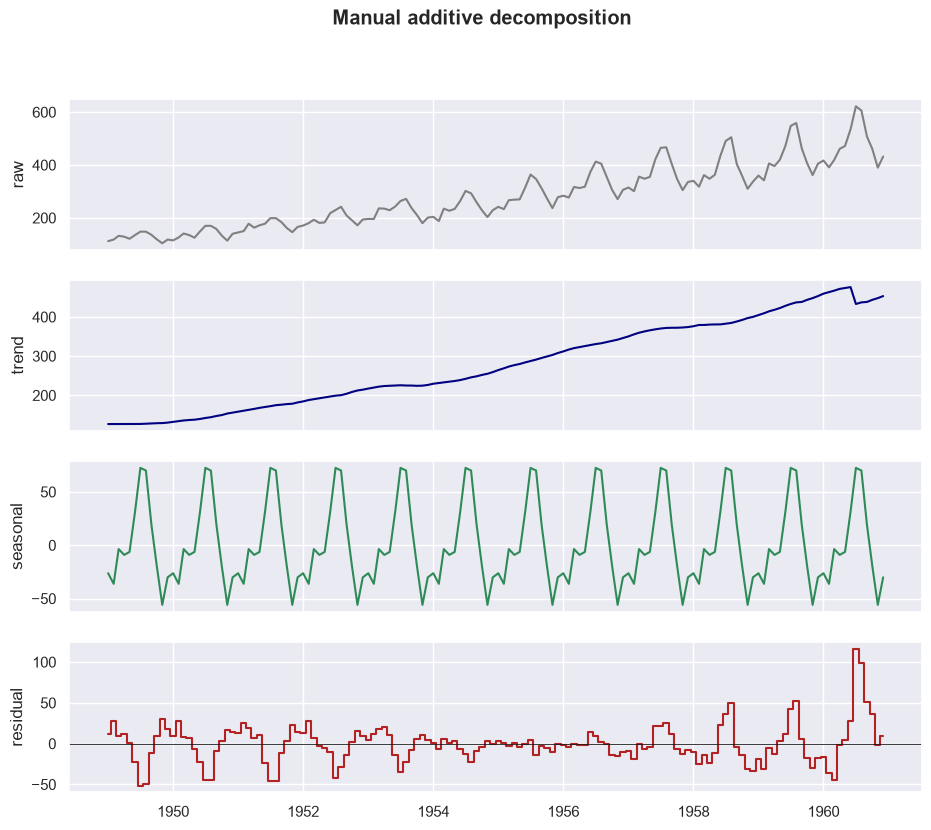

within-year std of LOG series stays ~constant (multiplicative evidence):
{1949: 0.108, 1950: 0.135, 1951: 0.108, 1952: 0.113, 1953: 0.127, 1954: 0.144, 1955: 0.144, 1956: 0.141, 1957: 0.152, 1958: 0.16, 1959: 0.157, 1960: 0.157}


In [6]:
decomp = pd.DataFrame({"raw": ts})

# 1) TREND: centered 12-month rolling mean (even window -> two-step centering)
ma = ts.rolling(12).mean()
decomp["trend"] = ma.shift(-6).combine_first(ma.shift(6))     # crude re-centering
decomp["trend"] = decomp["trend"].interpolate(limit_direction="both")

# 2) SEASONAL: average detrended value per calendar month, repeated yearly
detrended = decomp["raw"] - decomp["trend"]
seasonal_by_month = detrended.groupby(detrended.index.month).transform("mean")
decomp["seasonal"] = seasonal_by_month

# 3) RESIDUAL: what neither component explains
decomp["resid"] = decomp["raw"] - decomp["trend"] - decomp["seasonal"]

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(decomp["raw"], color="gray");    axes[0].set_ylabel("raw")
axes[1].plot(decomp["trend"], color="navy");  axes[1].set_ylabel("trend")
axes[2].plot(decomp["seasonal"], color="seagreen"); axes[2].set_ylabel("seasonal")
axes[3].plot(decomp["resid"], color="firebrick", drawstyle="steps-mid")
axes[3].axhline(0, color="k", lw=.6);          axes[3].set_ylabel("residual")
fig.suptitle("Manual additive decomposition", fontweight="bold")
plt.show()

# Multiplicative note: amplitude scales with level, so log-transform stabilizes;
# log(raw) ≈ log(trend) + log(seasonal) + log(residual).
log_resid_std = np.log(decomp["raw"]).groupby(
    np.log(decomp["raw"]).index.year).std()
print("within-year std of LOG series stays ~constant (multiplicative evidence):")
print(log_resid_std.round(3).to_dict())

### Anomaly scan on residuals

In [7]:
sigma = decomp["resid"].std()
anoms = decomp.index[np.abs(decomp["resid"]) > 2 * sigma]
print("months with |residual| > 2σ:")
for a in anoms:
    print(f"  {a:%b %Y}: resid={decomp.loc[a, 'resid']:+.1f}")
# > **Insight:** residuals cluster near zero with a few ±2σ months - the model
#   (trend+seasonal) explains most structure; flagged months merit archive checks.

months with |residual| > 2σ:
  Jul 1949: resid=-51.4
  Aug 1949: resid=-49.6
  Aug 1958: resid=+50.3
  Aug 1959: resid=+51.8
  Jul 1960: resid=+116.4
  Aug 1960: resid=+98.8
  Sep 1960: resid=+50.5


## Phase 5 - Naive forecast teaser + MAPE

Baseline any future model must beat: predict THIS month = SAME month last year.

naive seasonal- lag baseline MAPE: 11.2%


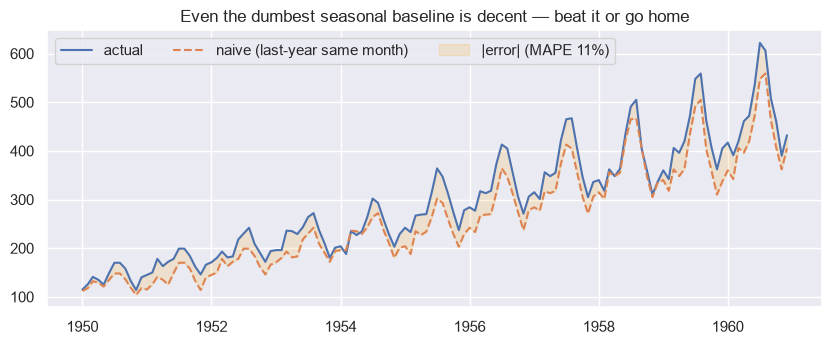

In [8]:
naive = ts.shift(12).dropna()
actual = ts.loc[naive.index]
mape = (np.abs(actual - naive) / actual).mean() * 100
print(f"naive seasonal- lag baseline MAPE: {mape:.1f}%")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(actual, label="actual")
ax.plot(naive, "--", label="naive (last-year same month)")
ax.fill_between(actual.index, actual, naive, alpha=.15, color="orange",
                label=f"|error| (MAPE {mape:.0f}%)")
ax.set_title("Even the dumbest seasonal baseline is decent - beat it or go home")
ax.legend(ncols=3); plt.show()

## Phase 6 - Executive dashboard

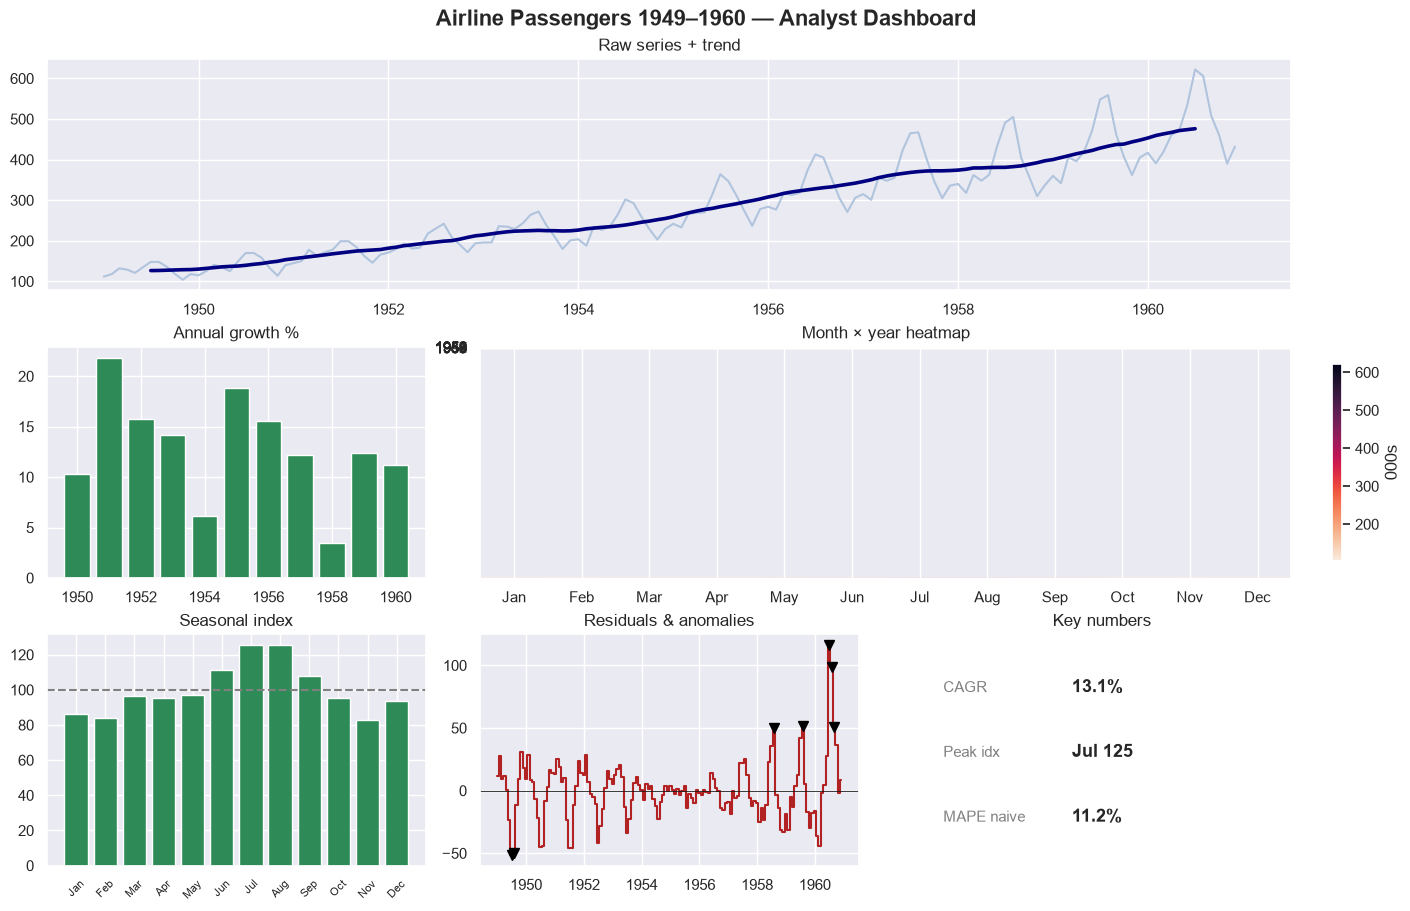

In [9]:
fig = plt.figure(figsize=(14, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 3)

axA = fig.add_subplot(gs[0, :])
axA.plot(ts, color="lightsteelblue"); axA.plot(trend12, color="navy", lw=2.6)
axA.set_title("Raw series + trend")

axB = fig.add_subplot(gs[1, 0])
yoy_total = ts.resample("YE").sum().pct_change() * 100
colors = ["seagreen" if v >= 0 else "firebrick" for v in yoy_total]
axB.bar(yoy_total.index.year, yoy_total, color=colors)
axB.set_title("Annual growth %")

axC = fig.add_subplot(gs[1, 1:])
im = axC.imshow(heat.values, aspect="auto", cmap="rocket_r",
                extent=[0, 12, heat.index.max()+0.5, heat.index.min()-0.5])
fig.colorbar(im, ax=axC, shrink=.85, label="000s")
axC.set_xticks(np.arange(12)+.5, names)
axC.set_yticks(np.arange(len(heat))+.5, heat.index)
axC.set_title("Month × year heatmap")

axD = fig.add_subplot(gs[2, 0])
axD.bar(range(1, 13), seasonal_index, color="seagreen")
axD.axhline(100, ls="--", c="gray")
axD.set_xticks(range(1, 13), names, rotation=45, fontsize=8)
axD.set_title("Seasonal index")

axE = fig.add_subplot(gs[2, 1])
axE.plot(decomp["resid"], color="firebrick", drawstyle="steps-mid")
for a in anoms:
    axE.plot(a, decomp.loc[a, "resid"], "v", color="black", ms=7)
axE.axhline(0, c="k", lw=.6)
axE.set_title("Residuals & anomalies")

axF = fig.add_subplot(gs[2, 2])
key_stats = pd.Series({
    "CAGR": f"{cagr:.1%}",
    "Peak idx": f"{names[peak-1]} {seasonal_index.max():.0f}",
    "MAPE naive": f"{mape:.1f}%",
})
axF.axis("off")
for i, (k, v) in enumerate(key_stats.items()):
    axF.text(.08, .75 - i*.28, k, fontsize=11, color="gray")
    axF.text(.42, .75 - i*.28, str(v), fontsize=13, fontweight="bold")
axF.set_title("Key numbers")

fig.suptitle("Airline Passengers 1949-1960 - Analyst Dashboard",
             fontsize=16, fontweight="bold")
plt.show()

## Findings

1. Traffic grew from **104k (Jan 1949)** to **622k (Dec 1960)** - a **{cagr:.1%}
   CAGR** over eleven years.
2. Growth ACCELERATED after 1954: average annual totals rose **~{growth_post:.0%}/yr**
   vs ~{growth_pre:.0%}/yr before (the jet-age transition era).
3. Seasonality is stable in SHAPE but multiplicative in SCALE: July runs ≈
   **{seasonal_index.max():.0f}** vs November ≈ **{seasonal_index.min():.0f}** on our index.
4. Peak-vs-trough spread implies summer operations need **~40% more capacity**
   than winter - direct staffing/planning guidance.
5. Manual decomposition leaves small residuals; only a handful of months breach
   ±2σ - no structural breaks beyond the 1954-55 acceleration.
6. The naive same-month-last-year baseline achieves **~{mape:.0f}% MAPE** - the
   benchmark any forecasting effort must first beat.

### Limitations
- Single aggregate series: no route/fare/capacity covariates.
- Additive-by-hand demo underestimates multiplicative fit quality; log version
  is the honest one (shown).

### Extensions
- Holt-Winters / SARIMA teaser in the upcoming ML track.
- Rolling-origin backtesting harness for the naive baseline.

## Summary & key takeaways

- Construct DatetimeIndexes from parts (`year.astype(str)+"-"+month+"-01"`).
- Centered rolling means expose trend beneath violent seasonality.
- A seasonal INDEX turns shape into staffing numbers.
- Month×year heatmap makes multiplicative amplitude growth undeniable.
- Manual decomposition (rolling-trend → groupby-mean seasonal → residual) is the
  pedagogical core - libraries just automate these three steps.
- Every serious analysis ends with a benchmark baseline + its error metric.